In [21]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

con = sqlite3.connect('C:\\Users\\faraz\\OneDrive\\Documents\\SEM 3\\project 3.1\\Data\\raw\\ipl.db')
def q(sql):
    return pd.read_sql(sql, con)

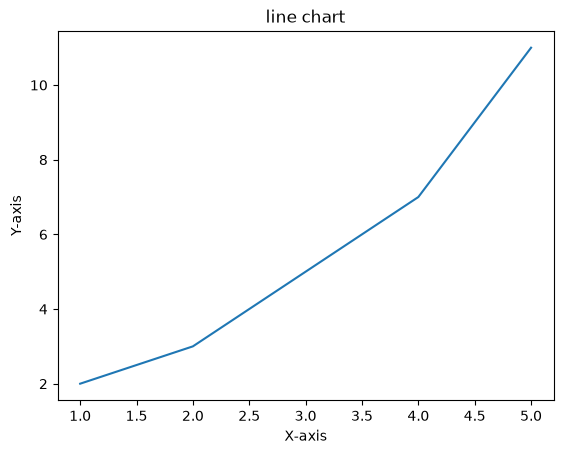

In [22]:
x=[1, 2, 3, 4, 5]
y=[2, 3, 5, 7, 11]

plt.plot(x, y)
plt.title("line chart")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

<Axes: title={'center': 'Total balls in each phase'}, xlabel='Different Phases of innings', ylabel='Total number of Balls'>

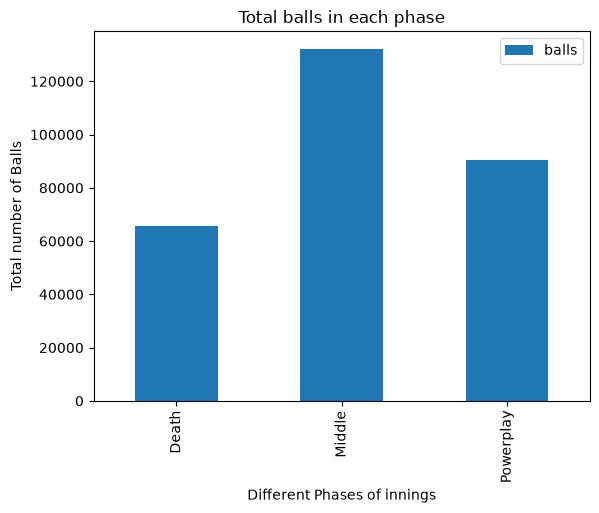

In [23]:
df=pd.read_sql("""select phase,count(*)as balls from v_ball group by phase;""",con)
df.plot(kind="bar",
x="phase",
y="balls",
title="Total balls in each phase",
xlabel="Different Phases of innings",
ylabel="Total number of Balls")


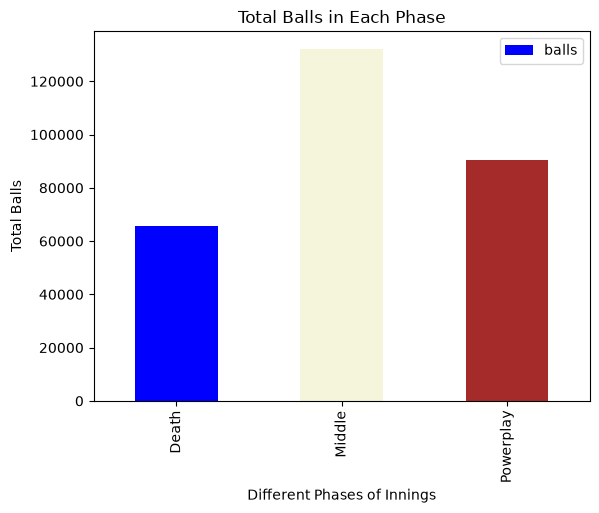

In [24]:
df=pd.read_sql("""select phase,count(*) as balls from v_ball group by phase;""",con)

df.plot(kind="bar", x="phase", y="balls",
        color=["blue","beige","brown"],
        title="Total Balls in Each Phase")

plt.xlabel("Different Phases of Innings")
plt.ylabel("Total Balls")
plt.show()

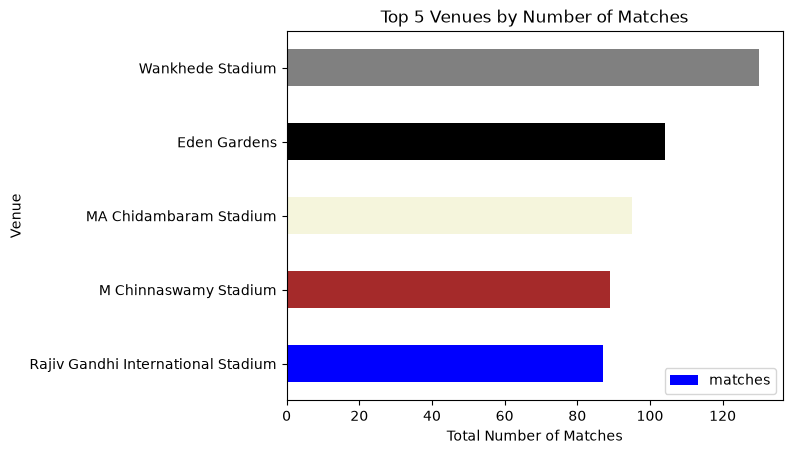

In [37]:
df = pd.read_sql("""SELECT venue_clean, COUNT(*) AS matches
FROM v_matches_venue
GROUP BY venue_clean
ORDER BY matches DESC
LIMIT 5;""", con).sort_values("matches")

df.plot(kind="barh",
        x="venue_clean",
        y="matches",
        color=["blue", "brown", "beige", "black", "gray"],
        title="Top 5 Venues by Number of Matches",
        xlabel="Total Number of Matches",
        ylabel="Venue")

plt.show()

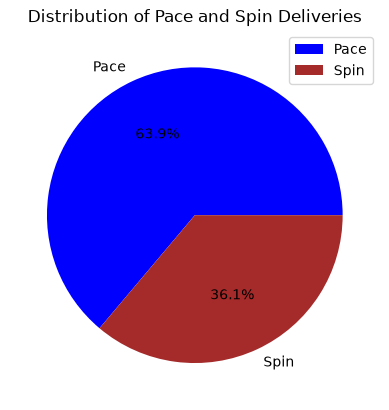

In [38]:
df = pd.read_sql("""SELECT CASE WHEN bowler_type LIKE
       '%Legbreak%' OR bowler_type LIKE
       '%Offbreak%' OR bowler_type LIKE
       '%Orthodox%' OR bowler_type LIKE
       '%Wrist spin%' OR bowler_type LIKE
       '%Googly%' THEN 'Spin' ELSE 'Pace'
       END AS style,
       SUM(is_legal) AS balls
FROM v_ball
WHERE bowler_type IS NOT NULL
AND TRIM(bowler_type) <> ''
GROUP BY style;""", con)

df.plot(kind="pie",
        y="balls",
        labels=df["style"],
        title="Distribution of Pace and Spin Deliveries",
        autopct="%1.1f%%",
        colors=["blue", "brown"])

plt.ylabel("")
plt.show()

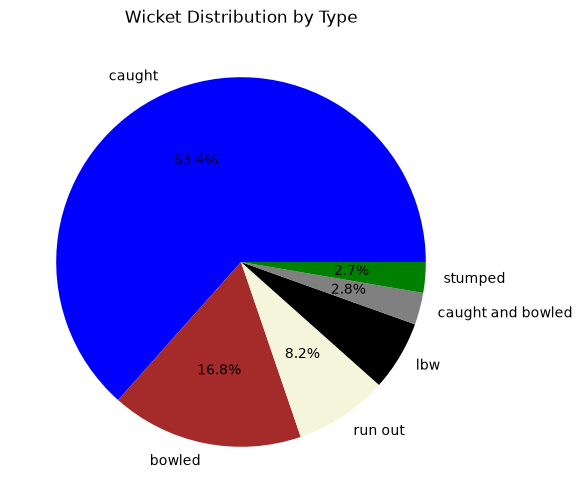

In [43]:
df = q("""
SELECT wicket_kind, COUNT(*) AS wickets
FROM v_ball
WHERE wicket_kind IS NOT NULL
GROUP BY wicket_kind
ORDER BY wickets DESC
LIMIT 6;
""")

df.plot(kind="pie",
        y="wickets",
        labels=df["wicket_kind"],
        title="Wicket Distribution by Type",
        autopct="%1.1f%%",
        figsize=(6,6),
        legend=False,
        colors=["blue", "brown", "beige", "black", "gray", "green"])

plt.ylabel("")
plt.show()

<Axes: title={'center': 'Top 10 Players by Player of the Match Awards'}, xlabel='Player', ylabel='Awards Won'>

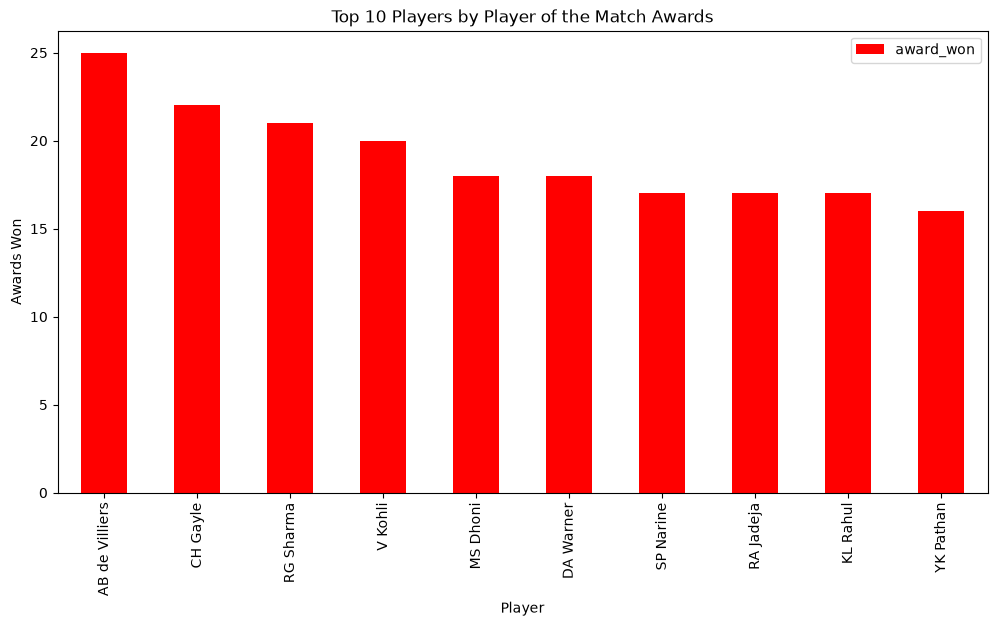

In [33]:
df = q("""
SELECT player_of_match,
       COUNT(*) AS award_won
FROM matches_clean
GROUP BY player_of_match
ORDER BY award_won DESC
LIMIT 10;
""")

df.plot(kind="bar",
        x="player_of_match",
        y="award_won",
        title="Top 10 Players by Player of the Match Awards",
        xlabel="Player",
        ylabel="Awards Won",
        figsize=(12,6),
        color="red")

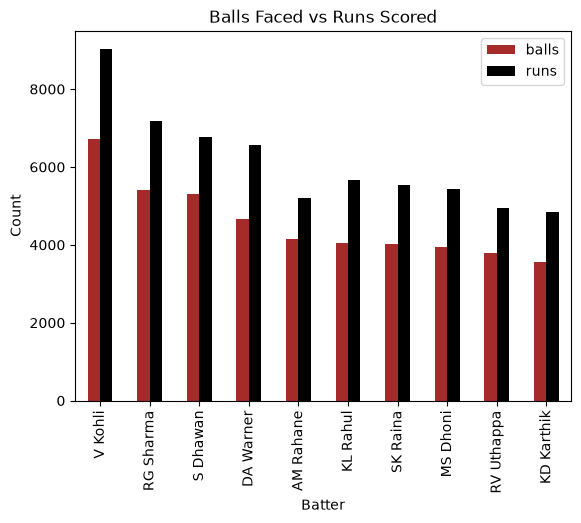

In [32]:
df = q("""SELECT batter, 
       SUM(is_legal) AS balls,
       SUM(batter_runs) AS runs,
       ROUND(100.0 * SUM(batter_runs) / SUM(is_legal), 2) AS strike_rate
FROM v_ball
GROUP BY batter
ORDER BY balls DESC
LIMIT 10;""")

df.plot(kind="bar",
        x="batter",
        y=["balls", "runs"],
        color=["brown", "black"],
        title="Balls Faced vs Runs Scored",
        xlabel="Batter",
        ylabel="Count")

plt.show()

<Axes: title={'center': 'Top 10 Batters by Number of Sixes'}, xlabel='Batters', ylabel='Total Number of Sixes'>

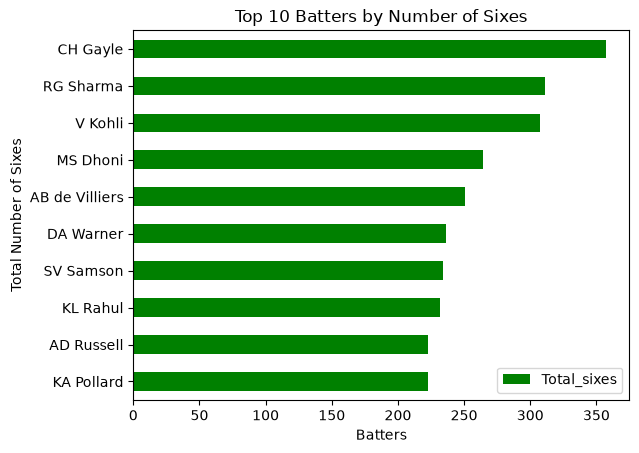

In [40]:
df = pd.read_sql("""SELECT batter,
       SUM(CASE WHEN batter_runs=6
                THEN 1
                ELSE 0
           END) AS Total_sixes
FROM v_ball
GROUP BY batter
ORDER BY Total_sixes DESC
LIMIT 10;""", con).sort_values("Total_sixes")

df.plot(kind="barh",
        x="batter",
        y="Total_sixes",
        title="Top 10 Batters by Number of Sixes",
        xlabel="Batters",
        ylabel="Total Number of Sixes",
        color="green")